# Atividade de Construção I — A ficha que você teria de defender

            **Computação Cognitiva · Ciência de Dados e Negócios · ESPM · 2026.2 · Prof. André Insardi**

            **Integrantes**

            - João Pedro Mascena
- Felipe Lira
- Felipe Murakami
- Pietro Garbin

            > Preencha os nomes acima **e** a lista `INTEGRANTES` na célula de setup (ou regenere
            > com `python scripts/build_notebook.py --integrantes "Nome Sobrenome" ...`). O nome
            > dos três arquivos de entrega (`AtividadeI_<sobrenomes>`) é derivado dessa lista.

            **Declaração de uso de IA (Seção 7).** Usamos assistentes de IA para escrever partes do
            código do pacote `ficha` e revisar textos. Todas as decisões de projeto, os números e
            as conclusões foram verificados pelo grupo, que sabe explicar cada linha entregue.

            **Como ler este notebook.** Toda a lógica (limpeza, seleção, prompt, parse, auditoria,
            custo, relatório) vive no pacote testado `src/ficha`; aqui só orquestramos e
            mostramos resultados (ADR 0001). Há dois modos:

            - `MODO = "ensaio"`: `FakeLLM` determinístico + PDFs sintéticos gerados na hora —
              roda em segundos, sem GPU nem rede, e prova que o pipeline inteiro funciona.
              **Os números do modo ensaio não são resultados da atividade.**
            - `MODO = "real"`: os 19 PDFs em `data/raw` + Qwen2.5-3B-Instruct na T4 do Colab
              (ou o backend declarado). É este que gera a entrega.

## 1. Setup

**No Colab, antes de qualquer célula:** *Ambiente de execução → Alterar tipo → GPU T4*
(a troca reinicia a sessão). Depois:

1. suba `ficha.zip` (gerado por `make colab-zip`) para `/content/`;
2. suba os 19 PDFs para `/content/ficha/data/raw/` (ou aponte `RAW_DIR` para o Drive);
3. se for usar API, cadastre a chave nos **Secrets** do Colab (ícone de chave) com o nome
   `ANTHROPIC_API_KEY` — ela é lida para o ambiente **sem ser impressa**.

Sementes fixas em `random`, `numpy` e `torch` (Seção 7, Reprodutibilidade).

In [1]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

INTEGRANTES = ['João Pedro Mascena', 'Felipe Lira', 'Felipe Murakami', 'Pietro Garbin']
MODO = os.environ.get("FICHA_MODO", "ensaio")  # troque para "real" na entrega
BACKEND_REAL = "qwen_local"  # ou "anthropic" / "openai_compat" (declare no relatório)
RAW_DIR = None  # ex.: Path("/content/drive/MyDrive/artigos") — None = data/raw
# Reutiliza execuções já gravadas em data/runs (mesma configuração) em vez de chamar
# o modelo de novo — ver seção 6. FICHA_REUSAR=0 força reexecutar tudo.
REUSAR_EXECUCOES = os.environ.get("FICHA_REUSAR", "1") == "1"

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    ROOT = Path("/content/ficha")
    if not ROOT.exists() and Path("/content/ficha.zip").exists():
        shutil.unpack_archive("/content/ficha.zip", ROOT)
    extras = "local,embeddings,api"
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"ficha[{extras}] @ file://{ROOT}"],
        check=True,
    )
else:
    cwd = Path.cwd()
    ROOT = Path(os.environ.get("FICHA_ROOT", cwd.parent if cwd.name == "notebooks" else cwd))
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

if IN_COLAB:  # chaves: Secrets do Colab → ambiente, nunca impressas
    from google.colab import userdata

    for nome in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY"):
        try:
            valor = userdata.get(nome)
        except Exception:
            valor = None
        if valor:
            os.environ[nome] = valor

from ficha.extract import set_seeds
from ficha.llm.qwen_local import describe_gpu

set_seeds(42)
print(f"MODO={MODO} · reusar execuções={REUSAR_EXECUCOES} · Colab={IN_COLAB} · raiz={ROOT}")
print("GPU:", describe_gpu() or "nenhuma (ok no modo ensaio; no modo real use a T4)")
print("Chaves no ambiente (só presença):",
      {n: bool(os.environ.get(n)) for n in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY")})

MODO=real · reusar execuções=True · Colab=False · raiz=/Users/joaomascena/Developer/studies/Atividade Andre


GPU: nenhuma (ok no modo ensaio; no modo real use a T4)
Chaves no ambiente (só presença): {'ANTHROPIC_API_KEY': False, 'OPENAI_API_KEY': False}


## 2. Configuração declarada

Tudo o que o relatório precisa declarar vem de `ficha.config.Settings` (variáveis
`FICHA_*`, `.env` ou Secrets): modelo, temperatura, semente, parâmetros de seleção e a
**premissa de preço** usada na Seção 4.5. Nenhum segredo é impresso.

In [2]:
import json

import pandas as pd
from IPython.display import Image, display

from ficha.config import Settings, get_settings
from ficha.llm import FakeBehavior, build_client

pd.set_option("display.max_colwidth", 120)
if MODO == "ensaio":
    DATA_DIR = ROOT / "data" / "outputs" / "ensaio"
    shutil.rmtree(DATA_DIR, ignore_errors=True)  # ensaio sempre do zero
    settings = get_settings(data_dir=DATA_DIR, model_backend="fake")
    # Erros simulados para a auditoria ter o que encontrar (ver ficha.llm.fake).
    client = build_client(settings, behavior=FakeBehavior(
        broken_json_rate=0.25, invent_trecho_rate=0.2,
        invent_limitacao_rate=0.4, unstable_rate=0.3,
    ))
else:
    settings = get_settings(data_dir=ROOT / "data", model_backend=BACKEND_REAL)
    client = build_client(settings)
settings.ensure_dirs()
FIG_DIR = settings.outputs_dir / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)
count_tokens = client.count_tokens  # tokenizador real no Qwen; ~4 chars/token no fake

print(json.dumps(settings.declaracao(), ensure_ascii=False, indent=2))
print("cliente:", client.model_name)

{
  "modelo": "qwen_local:Qwen/Qwen2.5-3B-Instruct",
  "quantize_4bit": false,
  "temperatura": 0.0,
  "temperatura_alternativa": 0.7,
  "seed": 42,
  "embedding_model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "premissa_preco_usd_por_mtok": {
    "entrada": 3.0,
    "saida": 15.0,
    "fonte": "Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09"
  }
}
cliente: Qwen/Qwen2.5-3B-Instruct


## 3. Ingestão e limpeza do texto

`ficha.ingest` extrai o texto página a página com `pymupdf` e aplica uma limpeza
determinística e conservadora (Seção 4.1, último parágrafo): remove cabeçalhos e
rodapés repetidos e números de página soltos, desfaz a **hifenização de fim de linha**
(com vocabulário do próprio artigo para não quebrar compostos legítimos como
*state-of-the-art*), reconstrói parágrafos e normaliza espaços. O resultado fica em
cache (`data/processed`, com `sha256`) para que todas as execuções usem o mesmo texto.

In [3]:
from ficha.ingest import load_or_ingest
from ficha.ingest.synthetic import generate_synthetic_corpus
from ficha.report.overview import corpus_frame

raw_dir = Path(RAW_DIR) if RAW_DIR else settings.raw_dir
if MODO == "ensaio":
    artigos = generate_synthetic_corpus(raw_dir, n=6, seed=settings.seed)
    # Gabarito conhecido: quais artigos declaram limitação (null esperado nos demais).
    GABARITO_LIMITACAO = {a.arquivo: a.has_limitations for a in artigos}
else:
    GABARITO_LIMITACAO = None  # sem gabarito: a auditoria usa a heurística declarada

pdfs = sorted(raw_dir.glob("*.pdf"))
assert pdfs, f"Nenhum PDF em {raw_dir}: suba os artigos antes de continuar."
docs = [load_or_ingest(p, settings.processed_dir) for p in pdfs]
corpus = corpus_frame(docs, count_tokens)
display(corpus)
total = corpus.iloc[-1]
print(f"{len(docs)} artigos · {total.paginas} páginas · {total.caracteres:,} caracteres · "
      f"~{total.tokens:,} tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)")
meta = docs[0].metadata
print({k: meta.get(k) for k in ("n_chars_raw", "n_chars_clean", "empty_pages")})

,arquivo,paginas,caracteres,tokens
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,30,80089,22085
1,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,2,11681,2737
2,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,2,7446,1720
3,06_Barnes_2016_Comparison_Flare_Forecasting_I_AllClear.pdf,43,129851,34977
4,07_Leka_2019_Comparison_Flare_Forecasting_II_Benchmarks.pdf,26,78908,21111
5,08_Leka_2019_Comparison_Flare_Forecasting_III_Systematic_Behaviors.pdf,23,58287,16803
6,09_AsensioRamos_2023_ML_in_Solar_Physics.pdf,89,281301,73401
7,11_Jarolim_2023_Coronal_Field_PINN.pdf,22,20459,5723
8,13_Camporeale_2020_GrayBox_Regional_Ground_Magnetic_Perturbations.pdf,20,48607,12438
9,14_Licata_Mehta_2022_UQ_DataDriven_Space_Weather.pdf,17,65345,17773


19 artigos · 476 páginas · 1,439,949 caracteres · ~392,936 tokens (enunciado: 19 artigos, ~476 páginas, ~1,4 M chars, ~350 k tokens)
{'n_chars_raw': 81670, 'n_chars_clean': 80089, 'empty_pages': []}


## 4. O que mandar para o modelo (Seção 4.1)

Três estratégias implementadas, todas com a mesma interface (`ContextSelector`):

| Estratégia | O que envia | Risco |
|---|---|---|
| `first_pages` | as N primeiras páginas | limitações e métricas costumam estar no fim |
| `keyword` | seções achadas por título (*Methods*, *Results*, *Limitations*...) | depende do nome da seção |
| `semantic` | blocos de ~1.200 caracteres (sobreposição de 200) mais próximos de consultas sobre problema, dados, método, métrica e limitação | depende da qualidade do embedding |

**Escolha: `semantic`**, com `keyword` como alternativa (ADR 0002). Blocos de 1.200
caracteres (~300 tokens, um parágrafo típico, a unidade em que autores declaram uma
limitação) com sobreposição de 200 (uma frase inteira: a evidência não é cortada);
8 consultas em português, uma ou duas por campo da ficha — incluindo "como o
desempenho foi medido" e "o que este trabalho não consegue fazer" —, embedder
multilíngue (as consultas são em português, os artigos em inglês) e blocos
reordenados por página. A busca vetorial aqui **não é o produto** — é só o modo de
escolher o que entra no prompt. A verificação 4.4c (seção 8)
testa essa escolha contra `first_pages`. Abaixo: o que cada estratégia envia para um
artigo, e o custo em tokens de cada uma no corpus inteiro.

In [4]:
from ficha.report.overview import selection_frame, strategy_summary
from ficha.select import SELECTOR_NAMES, HashingEmbedder, build_selector

if MODO == "ensaio" or importlib.util.find_spec("sentence_transformers") is None:
    embedder = HashingEmbedder()  # offline, determinístico
    if MODO == "real":
        print("ATENÇÃO: sentence-transformers ausente; usando HashingEmbedder (declare no relatório).")
else:
    embedder = None  # SentenceTransformer multilíngue das Settings
ESTRATEGIA = os.environ.get("FICHA_ESTRATEGIA", "semantic")  # principal (4.1)
ESTRATEGIA_ALT = "first_pages"  # comparação 4.4c
nomes = dict.fromkeys([*SELECTOR_NAMES, ESTRATEGIA, ESTRATEGIA_ALT])
selectors = {nome: build_selector(nome, settings, embedder) for nome in nomes}

exemplo = docs[0]
for nome, sel in selectors.items():
    ctx = sel.select(exemplo)
    texto = ctx.render()
    print(f"=== {nome}: páginas {list(ctx.pages)} · {len(ctx.chunks)} trechos · "
          f"{len(texto):,} chars · ~{count_tokens(texto):,} tokens · params={ctx.params}")
    print(texto[:500].rstrip(), "[...]\n")

=== first_pages: páginas [1, 2, 3] · 3 trechos · 7,667 chars · ~1,733 tokens · params={'n_pages': 3, 'max_chars': None, 'truncated': False}
[p. 1]
Verification of the NOAA Space Weather Prediction

Center solar flare forecast (1998-2024)

Enrico Camporeale1,2, Thomas E. Berger3

1School of Physical and Chemical Sciences, Queen Mary University of London, UK 2Space Weather Technology, Research and Education Center, University of Colorado, Boulder, CO, USA 3National Center for Atmospheric Research, High Altitude Observatory, Boulder, CO, USA

Key Points:

• SWPC solar flare forecasts do not outperform zero-cost baselines such as persis [...]

=== keyword: páginas [2, 4, 6, 7, 11, 21] · 6 trechos · 5,801 chars · ~1,331 tokens · params={'window_chars': 1500, 'max_chars': 6000, 'sections': None, 'sections_found': ['Abstract', '2 Data', '3 Methodology', '4 Results', '5 Conclusions'], 'fallback': None, 'sections_selected': ['Abstract', '3 Methodology', '2 Data', '4 Results', '5 Conclusions']}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

=== semantic: páginas [8, 9, 10, 16, 24, 30] · 7 trechos · 7,457 chars · ~1,608 tokens · params={'embedder': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'top_k': 6, 'chunk_size': 1200, 'overlap': 200, 'max_chars': 8000, 'merge_overlaps': True, 'queries': ['qual problema este trabalho tenta resolver e qual é o objetivo do estudo', 'que dados foram usados: fonte, período e volume do conjunto de dados', 'qual é o método ou a abordagem principal proposta pelos autores', 'como o desempenho foi medido', 'métricas de avaliação e resultados numéricos obtidos', 'o que este trabalho não consegue fazer', 'limitações declaradas pelos autores e ameaças à validade do estudo', 'principais resultados e contribuições do artigo'], 'n_chunks_total': 103, 'n_chunks_selected': 9}
[p. 8]
• Heidke Skill Score (HSS): the fractional improvement of the forecast over random chance:

HSS =

2(TP · TN −FN · FP) (TP + FN)(FN + TN) + (TP + FP)(FP + TN)

3.2 ROC Curve and Optimal Threshold

To eval

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

=== hybrid: páginas [4, 8, 9, 10, 13, 15, 16, 21, 23, 24, 29, 30] · 14 trechos · 12,130 chars · ~2,673 tokens · params={'max_chars': 12000, 'tail_pages': 0, 'cue_windows': 10, 'priority': ['limitations', 'cues', 'semantic', 'closing', 'tail'], 'limitation_sections': ['limitations'], 'closing_sections': ['discussion', 'conclusion', 'outlook'], 'keyword_window_chars': 1500, 'semantic': {'embedder': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'top_k': 6, 'chunk_size': 1200, 'overlap': 200, 'max_chars': 8000, 'merge_overlaps': True, 'queries': ['qual problema este trabalho tenta resolver e qual é o objetivo do estudo', 'que dados foram usados: fonte, período e volume do conjunto de dados', 'qual é o método ou a abordagem principal proposta pelos autores', 'como o desempenho foi medido', 'métricas de avaliação e resultados numéricos obtidos', 'o que este trabalho não consegue fazer', 'limitações declaradas pelos autores e ameaças à validade do estudo', 'principais resulta

In [5]:
selecao = selection_frame(docs, list(selectors.values()), count_tokens)
resumo_estrategias = strategy_summary(selecao)
display(resumo_estrategias)

,chunks_medios,caracteres_medios,tokens_medios,tokens_corpus,fracao_media_do_artigo
estrategia,,,,,
first_pages,2.9,10436,2428,46132,0.254
keyword,4.5,4950,1113,21152,0.136
semantic,6.9,7483,1829,34749,0.188
hybrid,12.5,11562,2809,53364,0.278


### A limitação declarada chega ao modelo?

O campo `limitacao` só pode ser preenchido se a frase em que os autores declaram a
limitação estiver no texto enviado. `ficha.select.recall_table` mede isso sobre o
**texto completo** de cada artigo: localiza as frases com declaração forte de
limitação ("a limitation of this study", "is limited by", "beyond the scope of this
work"...) e conta quantas chegam ao contexto de cada estratégia. É um diagnóstico
offline — não chama o modelo.

Se poucas chegam, o `null` em `limitacao` é sobretudo efeito da **seleção** (o modelo
não pode declarar o que não recebe), e não da abstenção do modelo.

In [6]:
import ficha.select as _select
from ficha.report.assemble import coverage_sentence, final_pages_share

recall_table = getattr(_select, "recall_table", None)
if recall_table is None:
    COBERTURA_LIMITACAO = ""
    print("recall_table ainda não existe no pacote.")
else:
    recall = recall_table(docs, selectors)
    display(recall)
    COBERTURA_LIMITACAO = coverage_sentence(recall, len(docs), final_pages_share(docs))
    if MODO == "real":  # revisão manual das frases detectadas (ADR 0002)
        COBERTURA_LIMITACAO += (
            " O detector é um regex ruidoso: na revisão manual só ~18 das frases são "
            "limitações admitidas pelos autores (precisão ≈ 30%, ADR 0002)."
        )
    print(COBERTURA_LIMITACAO)
    for d in docs[:4]:
        paginas = sorted({p for p, _ in _select.limitation_sentences(d)})
        print(f"  {d.arquivo[:30]}: frases de limitação nas páginas {paginas} de {d.n_pages}")

,estrategia,artigos_com_frases,artigos_cobertos,frases_total,frases_no_contexto,recall_frases,chars_medios
0,first_pages,15,6,63,8,0.127,10411
1,keyword,15,4,63,4,0.063,4910
2,semantic,15,6,63,9,0.143,7418
3,hybrid,15,9,63,19,0.302,11445


Das 63 frases em que os autores declaram limitação (15 dos 19 artigos têm ao menos uma), chegaram ao contexto enviado: first_pages 8 (13%; 6/15 artigos), keyword 4 (6%; 4/15 artigos), semantic 9 (14%; 6/15 artigos), hybrid 19 (30%; 9/15 artigos). Só 33% delas estão no último terço do artigo: estão espalhadas, e nenhuma estratégia de orçamento fixo cobre a maioria. O null em limitacao é sobretudo efeito da seleção (o modelo não declara o que não recebe), não da abstenção do modelo. O detector é um regex ruidoso: na revisão manual só ~18 das frases são limitações admitidas pelos autores (precisão ≈ 30%, ADR 0002).
  03_Camporeale_Berger_2025_Veri: frases de limitação nas páginas [11, 20, 28] de 30
  04_Lugaz_2021_ML_Research_Spac: frases de limitação nas páginas [2] de 2
  05_Lugaz_Morley_2025_Space_Wea: frases de limitação nas páginas [] de 2
  06_Barnes_2016_Comparison_Flar: frases de limitação nas páginas [11, 20, 41, 42] de 43


## 5. O prompt (Seção 4.2)

Cada técnica é um bloco com cabeçalho fixo, ligável/desligável por `PromptFeatures`
(ADR 0003): **papel** (`### PAPEL`, na mensagem de sistema), **instrução explícita** e
**formato de saída** com o schema JSON embutido, **delimitadores**
`<<<ARTIGO>>> ... <<<FIM_ARTIGO>>>` com o aviso de que nada ali dentro é ordem,
**few-shot** com dois exemplos — um deles com `limitacao: null` — e **abstenção**
("melhor `null` do que inventado"). A cadeia de raciocínio existe como variante
(`v_cot`, raciocínio num campo separado do JSON), mas não está na versão principal.

**Medição obrigatória:** `v_full` × `v_sem_fewshot` diferem **só** no few-shot.

**Temperatura 0,0.** Extração é tarefa de fidelidade: queremos a saída mais provável e
reprodutível (com semente fixa). A seção 8d mede o que muda com 0,7.

In [7]:
from ficha.prompts import build_prompt, describe_diff

builder = build_prompt("v_full")
rp = builder.render(selectors[ESTRATEGIA].select(exemplo))
print("Blocos presentes:", builder.markers_present(), "· template_sha:", builder.template_sha())
print("\n--- SYSTEM ---\n", rp.system)
print("\n--- USER (início) ---\n", rp.user[:2200], "\n[...]\n", rp.user[-400:])
print("\n", describe_diff("v_full", "v_sem_fewshot"))
print("\nTemperatura:", settings.temperature, "—", Settings.model_fields["temperature"].description)

Blocos presentes: ['### PAPEL', '### INSTRUÇÃO', '### FORMATO DE SAÍDA', '### REGRA DE ABSTENÇÃO', '### EXEMPLOS', '### ARTIGO'] · template_sha: e4ea67f171ac

--- SYSTEM ---
 ### PAPEL
Você é um assistente de pesquisa que prepara fichas de leitura de artigos científicos para uma tabela comparativa. Sua prioridade é a fidelidade ao texto: cada afirmação da ficha precisa poder ser defendida com um trecho do próprio artigo. Você nunca completa lacunas com conhecimento próprio nem com suposições plausíveis.

--- USER (início) ---
 ### INSTRUÇÃO
Leia o texto do artigo enviado abaixo (em inglês) e preencha a ficha, campo a campo:
- "problema": o que o trabalho tenta resolver, em uma frase.
- "dados": que dados usa — fonte, período e volume, quando informados.
- "metodo": a abordagem principal.
- "metrica": como o resultado é medido.
- "limitacao": a limitação que os PRÓPRIOS AUTORES declaram (não a sua opinião sobre o trabalho).
- "evidencia.trecho": um trecho COPIADO LITERALMENTE do texto e

## 6. Extração — matriz de execuções

Cada execução tem um `run_id` e grava **as saídas brutas** do modelo em
`data/runs/<run_id>/records.jsonl` (+ `manifest.json` com modelo, prompt, estratégia,
temperatura e semente). A saída passa por `parse_completion`: JSON validado pelo
schema (`FichaExtraida`, `extra="forbid"`); se vier malformado, tentamos reparos
registrados (cercas de código, vírgula final, aspas tipográficas) e o status fica
`repaired`; se nada funcionar, `failed` — o código trata e segue, não quebra.

| Execução | Prompt | Estratégia | Temperatura | Artigos | Serve para |
|---|---|---|---|---|---|
| a) principal | v_full | semantic | 0,0 | todos | tabela final |
| b) repetição | v_full | semantic | 0,0 | todos | 4.4b estabilidade |
| c) prompt alternativo | v_sem_fewshot | semantic | 0,0 | todos | 4.2 comparação |
| d) entrada alternativa | v_full | first_pages | 0,0 | todos | 4.4c efeito da entrada |
| e) temperatura | v_full | semantic | 0,7 | subconjunto | 4.4d temperatura |

**Reutilização (Seção 7, reprodutibilidade):** as saídas brutas gravadas são a fonte da
auditoria; com `REUSAR_EXECUCOES`, uma execução com a mesma configuração (estratégia,
variante, temperatura, repetição e artigos) é carregada de `data/runs` em vez de
refeita — reexecutar custa ~1 h de GPU e não muda a auditoria com decodificação gulosa
e seed fixa (a repetição da seção 8b mostra isso).

In [8]:
from ficha.extract import ExtractionRunner, RunResult, RunStore, reparse
from ficha.types import GenerationParams, ParseStatus

store = RunStore(settings.runs_dir)

def execucao_gravada(estrategia, variante, temperatura, repeticao, documentos):
    # run_id mais recente com a mesma configuração e os mesmos artigos, ou None.
    arquivos = sorted(d.arquivo for d in documentos)
    for run_id in reversed(store.list_runs()):
        try:
            m = store.manifest(run_id)
        except FileNotFoundError:
            continue
        if (m.get("status_execucao") == "concluida"
                and m["estrategia"]["nome"] == estrategia
                and m["prompt"]["variante"] == variante
                and float(m["temperatura"]) == float(temperatura)
                and m["repeticao"] == repeticao
                and m["n_docs"] == len(documentos)
                and sorted(m.get("arquivos", arquivos)) == arquivos):
            return run_id
    return None

def rodar(estrategia, variante, temperatura, repeticao, documentos):
    if REUSAR_EXECUCOES:
        run_id = execucao_gravada(estrategia, variante, temperatura, repeticao, documentos)
        if run_id is not None:
            res = RunResult(run_id, store.load(run_id), store.manifest(run_id))
            print(f"reutilizado: {run_id}: {res.status_counts()}")
            return res
    params = GenerationParams(temperature=temperatura, seed=settings.seed,
                              max_new_tokens=settings.max_new_tokens)
    runner = ExtractionRunner(client, selectors[estrategia], build_prompt(variante), params, store)
    res = runner.run(documentos, repetition=repeticao, show_progress=(MODO == "real"))
    print(f"{res.run_id}: {res.status_counts()}")
    return res

SUBCONJUNTO_T = docs[: max(3, len(docs) // 3)]  # 19 artigos → 6
execucoes = {
    "principal": rodar(ESTRATEGIA, "v_full", settings.temperature, 1, docs),
    "repeticao": rodar(ESTRATEGIA, "v_full", settings.temperature, 2, docs),
    "prompt_alt": rodar(ESTRATEGIA, "v_sem_fewshot", settings.temperature, 1, docs),
    "entrada_alt": rodar(ESTRATEGIA_ALT, "v_full", settings.temperature, 1, docs),
    "temperatura_alt": rodar(ESTRATEGIA, "v_full", settings.temperature_alt, 1, SUBCONJUNTO_T),
}
display(pd.DataFrame([
    {"execucao": k, "run_id": r.run_id, **r.status_counts(),
     "json_valido_de_primeira": r.manifest["resumo"]["taxa_json_valido_de_primeira"]}
    for k, r in execucoes.items()
]))

reutilizado: 20260923-144026_semantic_v_full_t0.0_rep1: {'ok': 19, 'repaired': 0, 'failed': 0}
reutilizado: 20260923-145329_semantic_v_full_t0.0_rep2: {'ok': 19, 'repaired': 0, 'failed': 0}
reutilizado: 20260923-150455_semantic_v_sem_fewshot_t0.0_rep1: {'ok': 19, 'repaired': 0, 'failed': 0}
reutilizado: 20260923-151736_first_pages_v_full_t0.0_rep1: {'ok': 19, 'repaired': 0, 'failed': 0}
reutilizado: 20260923-152920_semantic_v_full_t0.7_rep1: {'ok': 6, 'repaired': 0, 'failed': 0}


,execucao,run_id,ok,repaired,failed,json_valido_de_primeira
0,principal,20260923-144026_semantic_v_full_t0.0_rep1,19,0,0,1.0
1,repeticao,20260923-145329_semantic_v_full_t0.0_rep2,19,0,0,1.0
2,prompt_alt,20260923-150455_semantic_v_sem_fewshot_t0.0_rep1,19,0,0,1.0
3,entrada_alt,20260923-151736_first_pages_v_full_t0.0_rep1,19,0,0,1.0
4,temperatura_alt,20260923-152920_semantic_v_full_t0.7_rep1,6,0,0,1.0


Uma saída **bruta** do modelo, exatamente como foi gravada, e um caso que precisou de reparo ou falhou:

In [9]:
registros = execucoes["principal"].records
r0 = next((r for r in registros if r.parse_status == ParseStatus.OK), registros[0])
print(f"[{r0.run_id} · {r0.arquivo} · {r0.parse_status.value}]\n{r0.raw_output[:1500]}")

problemas = [r for res in execucoes.values() for r in res.records if r.parse_status != ParseStatus.OK]
if problemas:
    rp_ = problemas[0]
    print(f"\n[{rp_.run_id} · {rp_.arquivo} · {rp_.parse_status.value}] "
          f"reparos={reparse(rp_).repairs} erro={rp_.error}\n{rp_.raw_output[:1200]}")
else:
    print("\nNenhuma saída precisou de reparo nesta rodada — isso também é resultado.")

[20260923-144026_semantic_v_full_t0.0_rep1 · 03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf · ok]
{
  "problema": "Evaluar o desempenho de modelos de previsão probabilística para eventos rares, como erupções solares, usando métricas adequadas para contextos desbalanceados.",
  "dados": "9,828 dias de dados de erupções solares, com M-class flares em 20.6% dos dias e X-class flares em 2.6% dos dias.",
  "metodo": "Modelos de regressão logística, climatologia, Naive Bayes e persistência, com métricas como Brier Score, True Skill Statistic (TSS) e Heidke Skill Score (HSS).",
  "metrica": "AUC (Área sob a curva ROC) e TSS (True Skill Statistic).",
  "limitacao": null,
  "evidencia": {
    "trecho": "The extreme imbalance between flare and no-flare days poses challenges for evaluating forecast skill. For example, in our dataset of 9,828 days, M-class flares occurred only on 20.6% of days and X-class flares only on 2.6%. As a result, a model that always predicts no flare 

## 7. Comparação das duas versões do prompt (Seção 4.2)

Mesmos artigos, mesma estratégia, mesma temperatura; só o few-shot muda. Medimos a taxa
de **JSON válido de primeira**, a taxa de **`null` quando a informação não existe**
(no ensaio contra o gabarito dos PDFs sintéticos; no real pela heurística de
vocabulário declarada em `ficha.audit.runstats`), a fidelidade e **em que campos as
fichas discordam**. A versão final sai da regra declarada
(`PromptComparison.decide`: JSON válido → fidelidade → null correto), não da intuição.

,v_full,v_sem_fewshot,delta (b-a)
n,19.000000,19.000000,0.000000
rate_json_valid_first_try,1.000000,1.000000,0.000000
rate_parse_ok,1.000000,1.000000,0.000000
rate_parse_repaired,0.000000,0.000000,0.000000
rate_parse_failed,0.000000,0.000000,0.000000
rate_limitacao_null,0.947368,1.000000,0.052632
rate_null_when_expected,1.000000,1.000000,0.000000
n_null_expected,8.000000,8.000000,0.000000
rate_fidelity,0.947368,0.789474,-0.157895
rate_page_ok,0.842105,0.526316,-0.315789


Vencedora: v_full — v_full vence por rate_fidelity: 0.947 (v_full) vs 0.789 (v_sem_fewshot); critérios anteriores empataram.


,arquivo,field,a,b,equal,similarity
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,problema,"Evaluar o desempenho de modelos de previsão probabilística para eventos rares, como erupções solares, usando métrica...",Evaluar o desempenho de modelos de previsão probabilística de erupções solares em comparação com modelos de base de ...,False,0.6344
1,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,dados,"9,828 dias de dados de erupções solares, com M-class flares em 20.6% dos dias e X-class flares em 2.6% dos dias.","Dados de erupções solares de 1980 a 2022, com 9.828 dias de observação.",False,0.5027
2,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,metodo,"Modelos de regressão logística, climatologia, Naive Bayes e persistência, com métricas como Brier Score, True Skill ...",Evaluam o desempenho de modelos de previsão probabilística de erupções solares em comparação com modelos de base de ...,False,0.4096
3,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,metrica,AUC (Área sob a curva ROC) e TSS (True Skill Statistic).,"True Skill Statistic (TSS), Probability of Detection (POD), Critical Success Index (CSI), Heidke Skill Score (HSS), ...",False,0.3587
4,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,evidencia.trecho,"The extreme imbalance between flare and no-flare days poses challenges for evaluating forecast skill. For example, i...","The poor calibration and elevated FARs associated with the SWPC model suggest that the forecasts, in their current f...",False,0.3591
5,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,evidencia.pagina,10,24,False,0.0000
6,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,problema,Comparar resultados de previsões usando diferentes métodos publicados para avaliar o avanço de novas técnicas de apr...,Resolver a falta de comparação adequada entre métodos de aprendizado de máquina em estudos de fenômenos espaciais.,False,0.5092
7,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,metodo,Inclui o software e/ou algoritmos usados para desenvolver a técnica de aprendizado de máquina em um repositório ao s...,"Comparação entre diferentes estudos usando métodos de aprendizado de máquina, apresentando comparações com modelos e...",False,0.5026
8,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,metrica,não informado,"Quantificar a qualidade do método além de correlação, RMSE e MAE, seguindo exemplos específicos fornecidos em Space ...",False,0.1366
9,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,evidencia.trecho,The lack of sufficient comparison with published results using other methods has been one major obstacle to judging ...,The lack of sufficient comparison with published results using other methods has been one major obstacle to judging ...,False,0.6547


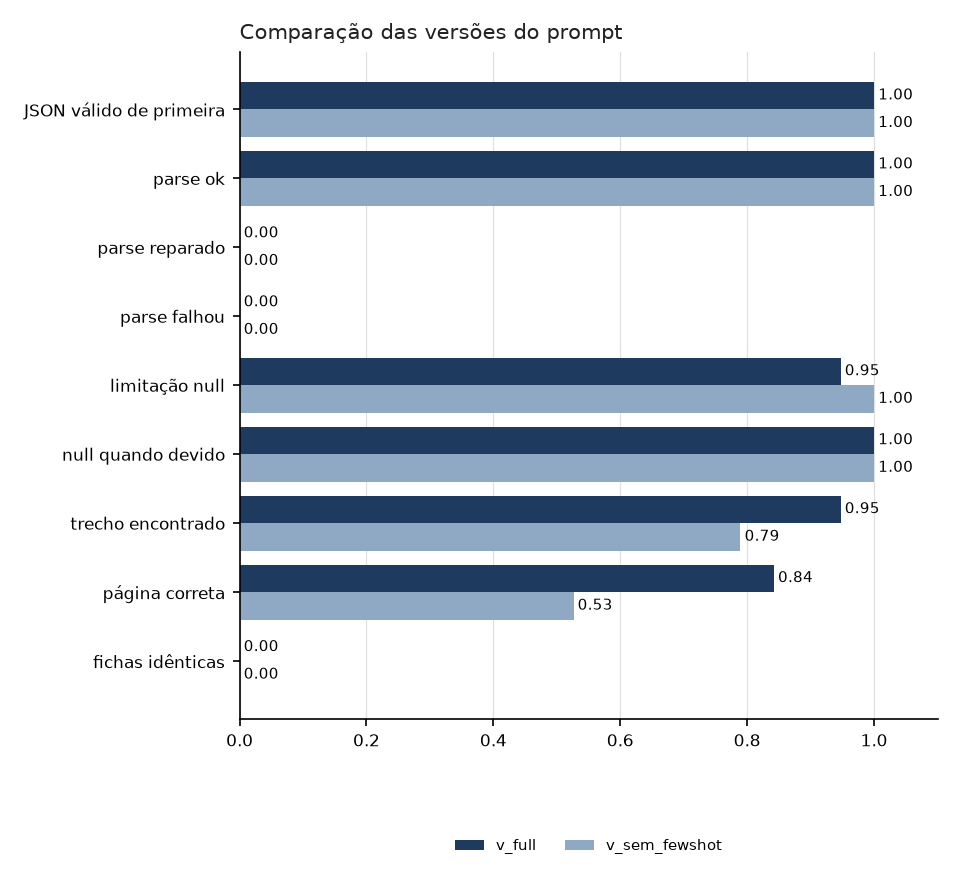

In [10]:
from ficha.audit import compare_prompt_variants
from ficha.report.figures import plot_prompt_comparison

comparacao = compare_prompt_variants(
    execucoes["principal"].records, execucoes["prompt_alt"].records,
    limitacao_gabarito=GABARITO_LIMITACAO,
)
tabela_prompts = comparacao.to_frame()
display(tabela_prompts)
veredito = comparacao.decide()
print("Vencedora:", veredito.winner, "—", veredito.explanation)
divergencias = pd.DataFrame([d.to_dict() for d in comparacao.disagreements()])
display(divergencias.head(10) if not divergencias.empty else "As fichas das duas versões não discordam.")

taxas = tabela_prompts.loc[[i for i in tabela_prompts.index if str(i).startswith("rate_")],
                           list(comparacao.variants)].astype(float)
fig_prompts = plot_prompt_comparison(taxas, FIG_DIR / "comparacao_prompts.png")
display(Image(filename=str(fig_prompts)))
# Versão compacta (só as taxas decisivas) para caber no relatório de 3 páginas.
chave = ["rate_json_valid_first_try", "rate_null_when_expected", "rate_fidelity"]
fig_prompts_relatorio = plot_prompt_comparison(
    taxas.loc[[k for k in chave if k in taxas.index]], FIG_DIR / "comparacao_prompts_relatorio.png"
)

## 8. Auditoria (Seção 4.4)

As quatro verificações, cada uma com números e uma frase de conclusão (ADR 0005).

- **a) Fidelidade** — `evidencia.trecho` é procurado no **texto que foi enviado** ao
  modelo (não no PDF inteiro): substring exata após normalização tipográfica; senão
  `partial_ratio` ≥ 0,90. Também conferimos se a página declarada bate com o marcador
  `[p. N]` onde o trecho está.
- **b) Estabilidade** — execução repetida sem mudar nada; diferença campo a campo.
- **c) Efeito da entrada** — `semantic` × `first_pages` nos mesmos artigos.
- **d) Efeito da temperatura** — 0,0 × 0,7 num subconjunto.

In [11]:
from ficha.audit import RULE_V1, RULE_V2, build_audit_summary
from ficha.report.assemble import fidelity_block, input_block, stability_block, temperature_block

resumo = build_audit_summary(
    execucoes["principal"].records,
    stability_rep=execucoes["repeticao"].records,
    alt_input=execucoes["entrada_alt"].records,
    t_alt=execucoes["temperatura_alt"].records,
    prompt_runs=(execucoes["principal"].records, execucoes["prompt_alt"].records),
    limitacao_gabarito=GABARITO_LIMITACAO,
    rule=RULE_V2,  # regra final — ver a calibração na seção 9
)
tabelas = resumo.tables()

def mostrar(bloco):
    print(f"{bloco.titulo}: " + " · ".join(f"{k}: {v}" for k, v in bloco.numeros.items()))
    print("→", bloco.conclusao)

mostrar(fidelity_block(resumo))
display(tabelas["fidelidade"])

a) Fidelidade: trecho encontrado: 18/19 (95%) · página correta: 16/19 · exato / aproximado / sem ficha: 17 / 2 / 0
→ 1/19 trecho(s) inventado(s), ausente(s) do texto enviado: 08_Leka_2019 (cópia do exemplo few-shot do prompt). Página errada em 2/19 (11_Jarolim_2023: declarada 15, encontrada 16; D04_Jiao_2020: declarada 18, encontrada 15): trecho real, mas a ficha não é rastreável como declarada — BAIXA.


,arquivo,run_id,found,score,method,page_claimed,page_found,page_ok,threshold
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,10,10.0,True,0.9
1,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,2,2.0,True,0.9
2,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,2,2.0,True,0.9
3,06_Barnes_2016_Comparison_Flare_Forecasting_I_AllClear.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,3,3.0,True,0.9
4,07_Leka_2019_Comparison_Flare_Forecasting_II_Benchmarks.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,15,15.0,True,0.9
5,08_Leka_2019_Comparison_Flare_Forecasting_III_Systematic_Behaviors.pdf,20260923-144026_semantic_v_full_t0.0_rep1,False,0.4727,fuzzy,5,NaN,False,0.9
6,09_AsensioRamos_2023_ML_in_Solar_Physics.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,55,55.0,True,0.9
7,11_Jarolim_2023_Coronal_Field_PINN.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,15,16.0,False,0.9
8,13_Camporeale_2020_GrayBox_Regional_Ground_Magnetic_Perturbations.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,5,5.0,True,0.9
9,14_Licata_Mehta_2022_UQ_DataDriven_Space_Weather.pdf,20260923-144026_semantic_v_full_t0.0_rep1,True,1.0000,exact,4,4.0,True,0.9


Como a fidelidade pega um trecho inventado: o trecho devolvido, o score e o que o texto enviado realmente tinha.

In [12]:
principal = {r.arquivo: r for r in execucoes["principal"].records}
falhas = resumo.fidelity.failures()
for f in falhas[:3]:
    rec = principal[f.arquivo]
    trecho = rec.ficha.evidencia.trecho if rec.ficha else "(sem ficha)"
    print(f"{f.arquivo}: score={f.score:.2f} ({f.method}) — trecho devolvido:\n  «{trecho}»")
    print(f"  início do texto enviado: «{rec.context_text[:300]}...»\n")
if not falhas:
    print("Todos os trechos foram encontrados no texto enviado.")

08_Leka_2019_Comparison_Flare_Forecasting_III_Systematic_Behaviors.pdf: score=0.47 (fuzzy) — trecho devolvido:
  «Forecast accuracy is measured with the weighted mean absolute percentage error (WMAPE) over a 13-week horizon.»
  início do texto enviado: «[p. 2]
sponsored by the ISEE Center for International Collaborative Research. In that paper, the methodology was presented: the agreed-upon testing interval, event definitions, and evaluation metrics were described. Specifically, daily operational full-disk forecasts from a variety of facilities wer...»



b) Estabilidade: pares comparados: 19 · fichas idênticas: 19/19 (100%) · campos que mais mudam: nenhum
→ 19/19 fichas idênticas nas duas execuções — esperado com decodificação gulosa e seed fixa. Por isso a variabilidade real do pipeline aparece no efeito da entrada (c) e da temperatura (d), não aqui.


,field,change_rate,mean_similarity
0,problema,0.0,1.0
1,dados,0.0,1.0
2,metodo,0.0,1.0
3,metrica,0.0,1.0
4,limitacao,0.0,1.0
5,evidencia.trecho,0.0,1.0
6,evidencia.pagina,0.0,1.0


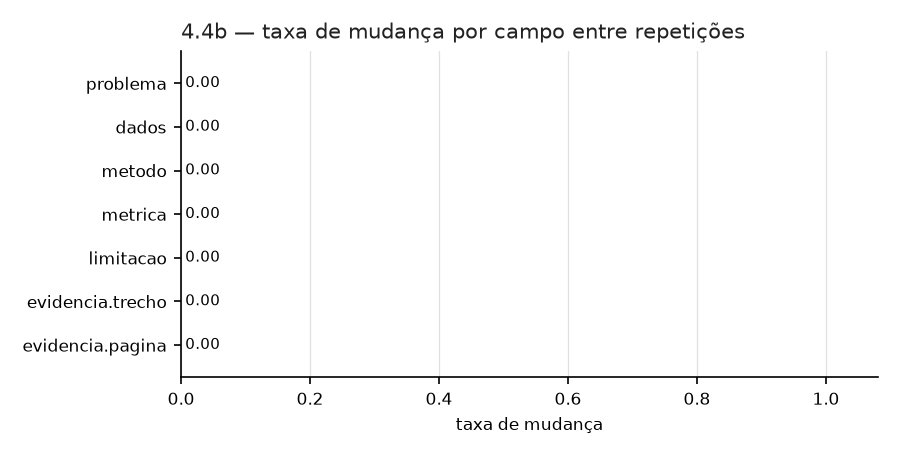

In [13]:
from ficha.report.figures import plot_field_change_rates

mostrar(stability_block(resumo))
display(tabelas["estabilidade_campos"])
fig_estab = plot_field_change_rates(
    tabelas["estabilidade_campos"][["field", "change_rate"]], FIG_DIR / "estabilidade_campos.png",
    title="4.4b — taxa de mudança por campo entre repetições",
)
display(Image(filename=str(fig_estab)))

c) Efeito da entrada: estratégias: semantic × first_pages · fichas idênticas: 0/19 · divergências substantivas: 103 · fidelidade: semantic 95% · first_pages 95% · campos que mais divergem: problema 100%, metodo 95%, dados 89% · limitacao null: semantic 18/19 · first_pages 19/19
→ Defendemos semantic: semantic vence por maior taxa de página correta (0.842 vs 0.684).


,semantic,first_pages
n,19.000000,19.000000
rate_json_valid_first_try,1.000000,1.000000
rate_parse_ok,1.000000,1.000000
rate_parse_repaired,0.000000,0.000000
rate_parse_failed,0.000000,0.000000
rate_limitacao_null,0.947368,1.000000
rate_null_when_expected,1.000000,1.000000
n_null_expected,8.000000,9.000000
rate_fidelity,0.947368,0.947368
rate_page_ok,0.842105,0.684211


,field,change_rate,mean_similarity
0,problema,1.000000,0.489021
1,metodo,0.947368,0.490479
2,dados,0.894737,0.462321
3,metrica,0.894737,0.494137
4,evidencia.pagina,0.842105,0.157895
5,evidencia.trecho,0.842105,0.482242
6,limitacao,0.052632,0.947368


,arquivo,field,a,b,equal,similarity
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,problema,"Evaluar o desempenho de modelos de previsão probabilística para eventos rares, como erupções solares, usando métrica...",Verificar a precisão dos previsões de erupções solares do NOAA Space Weather Prediction Center (SWPC) para M-class e...,False,0.4706
1,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,dados,"9,828 dias de dados de erupções solares, com M-class flares em 20.6% dos dias e X-class flares em 2.6% dos dias.","Catalogos de erupções solares mantidos, incluindo ASR v1.0.0 (2002-2024); período e volume não informados.",False,0.4679
2,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,metodo,"Modelos de regressão logística, climatologia, Naive Bayes e persistência, com métricas como Brier Score, True Skill ...","Comparação com várias bases de dados zero-cost e estatísticas, incluindo persistência, climatologia, Naive Bayes e r...",False,0.4218
3,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,metrica,AUC (Área sob a curva ROC) e TSS (True Skill Statistic).,"Avaliação de desempenho em termos de precisão e falsos alarmes, especialmente para erupções X-class e em cenários de...",False,0.3351
4,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,evidencia.trecho,"The extreme imbalance between flare and no-flare days poses challenges for evaluating forecast skill. For example, i...",The SWPC model does not outperform these baselines across key classification and probabilistic metrics and exhibits ...,False,0.3725
5,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,evidencia.pagina,10,2,False,0.0000
6,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,problema,Comparar resultados de previsões usando diferentes métodos publicados para avaliar o avanço de novas técnicas de apr...,Determinar a melhor abordagem de aprendizado de máquina para prever fenômenos espaciais semáforos.,False,0.4314
7,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,metodo,Inclui o software e/ou algoritmos usados para desenvolver a técnica de aprendizado de máquina em um repositório ao s...,"Análise de dados de fenômenos espaciais usando técnicas de aprendizado de máquina, incluindo técnicas de LSTM e méto...",False,0.4861
8,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,problema,"Promover a comunicação entre cientistas, engenheiros, técnicos, administradores de ciência e decisores de políticas ...",Desenvolver uma compreensão mais aprofundada e aprimorada da influência da weather espacial em tecnologia e sistemas...,False,0.4221
9,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,evidencia.trecho,"This has been done through editorials, commentaries, news articles, and the Space Weather Quarterly.","The incoming Editor-in-Chief, Dr. Steven K. Morley, will be starting in that role from 1 January 2026, and will cont...",False,0.3307


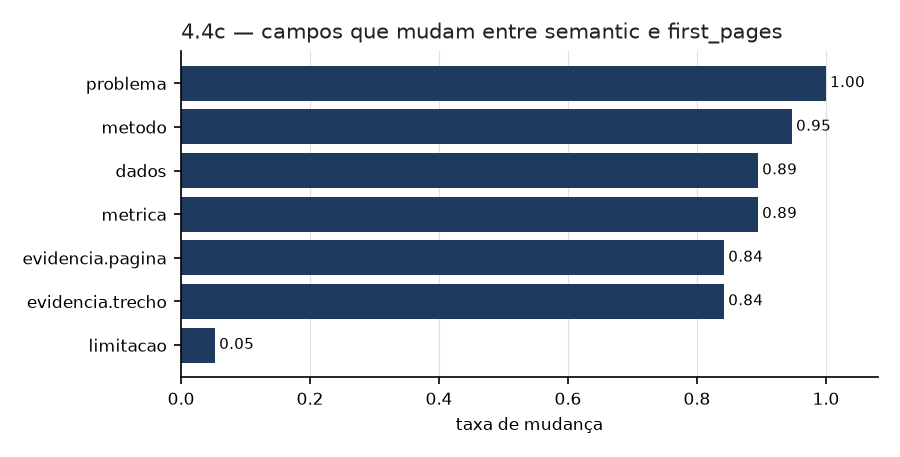

In [14]:
mostrar(input_block(resumo))
display(tabelas["entrada_estrategias"])
display(tabelas["entrada_campos"])
display(tabelas["entrada_divergencias"].head(10))
fig_entrada = plot_field_change_rates(
    tabelas["entrada_campos"][["field", "change_rate"]], FIG_DIR / "entrada_campos.png",
    title=f"4.4c — campos que mudam entre {ESTRATEGIA} e {ESTRATEGIA_ALT}",
)
display(Image(filename=str(fig_entrada)))

In [15]:
mostrar(temperature_block(resumo))
print("Critério declarado:", resumo.temperature.criterio)
display(tabelas["temperatura"])

d) Efeito da temperatura: subconjunto: 6 artigos · JSON válido de primeira: t=0,0: 100% · t=0,7: 100% · fidelidade: t=0,0: 83% · t=0,7: 100% · fichas idênticas: 0/6
→ Pelo critério declarado, t=0,0 não se sustenta neste subconjunto: t=0,7 teve fidelidade 100% vs 83% em t=0,0. Erro(s) em t=0,0: 08_Leka_2019 (vazamento do exemplo few-shot). Com n=6 artigos, a diferença não sustenta conclusão. Mantemos t=0,0 pela estabilidade (19/19 fichas idênticas entre repetições) e reportamos o resultado como está.
Critério declarado: A temperatura escolhida se sustenta se, no mesmo subconjunto de artigos, tiver taxa de fidelidade (trecho encontrado no texto enviado) maior ou igual e taxa de JSON válido de primeira maior ou igual às da temperatura alternativa.


,t=0.0,t=0.7
n,6.000000,6.0
rate_json_valid_first_try,1.000000,1.0
rate_parse_ok,1.000000,1.0
rate_parse_repaired,0.000000,0.0
rate_parse_failed,0.000000,0.0
rate_limitacao_null,1.000000,1.0
rate_null_when_expected,1.000000,1.0
n_null_expected,2.000000,2.0
rate_fidelity,0.833333,1.0
rate_page_ok,0.833333,0.5


## 9. Confiança — regra declarada e fichas que não defenderíamos

`confianca` nunca vem do modelo nem "do olho": é função determinística das verificações
acima (`ficha.audit.ConfidenceRule`). Cada ficha carrega os **motivos** que a
impediram de ter nível mais alto — é deles que sai a lista de fichas não defensáveis.

**Duas versões da regra, e por que a final é a v2.** A v1 (estrita) rebaixava uma ficha
se *qualquer* campo mudasse entre as duas estratégias de entrada. Os dados mostram que
isso mede redação, não confiabilidade: entre estratégias, a similaridade média dos
campos de texto livre fica em torno de 0,5 (entradas diferentes produzem paráfrases e
evidências de outras páginas por construção), enquanto entre repetições com a mesma
entrada é 1,00. A v2 compara estratégias só pela **discordância categórica** — a
limitação declarada numa e `null` na outra — e mantém a comparação exata entre
repetições. A tabela abaixo mostra as duas distribuições lado a lado; a tabela final e
o PDF usam a v2. A calibração foi decidida depois de ver os dados reais, e isso é
declarado aqui e no relatório.

In [16]:
from ficha.audit import build_final_fichas, confidence_distribution
from ficha.report.assemble import mean_text_similarity

args_regra = (execucoes["principal"].records, execucoes["repeticao"].records,
              execucoes["entrada_alt"].records)
DISTRIBUICOES = {
    "v1 estrita": confidence_distribution(build_final_fichas(*args_regra, RULE_V1)),
    "v2 categórica (final)": confidence_distribution(build_final_fichas(*args_regra, RULE_V2)),
}
display(pd.DataFrame(DISTRIBUICOES).rename_axis("confianca"))
sim_entrada = mean_text_similarity(resumo.input_effect.diff.field_mean_similarity)
sim_repeticao = mean_text_similarity(resumo.stability.diff.field_mean_similarity)
print(f"Similaridade média dos campos de texto livre: entre estratégias {sim_entrada:.2f} · "
      f"entre repetições {sim_repeticao:.2f}")

,v1 estrita,v2 categórica (final)
confianca,,
alta,0,15
media,2,1
baixa,17,3


Similaridade média dos campos de texto livre: entre estratégias 0.48 · entre repetições 1.00


Regra de confiança v2 (aplicada automaticamente; o nível final é o MENOR entre os limites abaixo):
- BAIXA se a extração falhou (nenhum JSON válido segundo o esquema), ou o trecho de evidência não foi encontrado no texto enviado ao modelo (similaridade partial_ratio normalizada < 0.90), ou o trecho foi encontrado numa página diferente da declarada em evidencia.pagina, ou mais de 2 campos mudaram entre as duas repetições (mesma entrada).
- MEDIA se a evidência passou, mas entre 1 e 2 campos mudaram entre as repetições, ou limitacao é null numa estratégia de entrada e preenchida na outra (discordância categórica), ou se alguma comparação não pôde ser feita (ausente ou sem ficha válida do outro lado): o que não foi verificado não recebe ALTA.
- No máximo MEDIA se o campo limitacao veio preenchido mas o texto enviado não contém nenhum termo de limitação (limitation, shortcoming, drawback, caveat, future work, threats to validity...), sinal de limitação possivelmente inventada. O caso inver

,confianca,n
0,alta,15
1,media,1
2,baixa,3


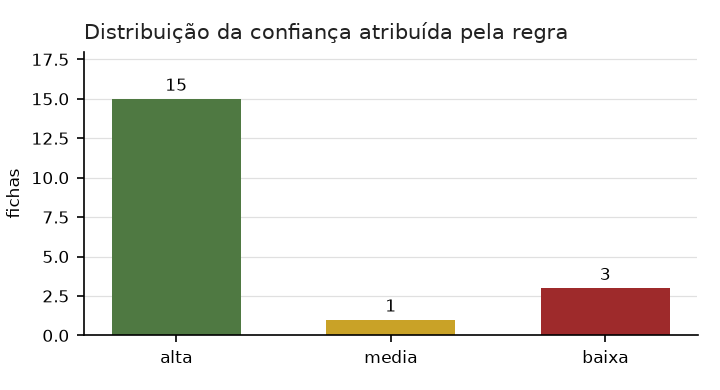

Fichas que NÃO defenderíamos (confiança baixa) e por quê:


,arquivo,confianca,motivos
0,08_Leka_2019_Comparison_Flare_Forecasting_III_Systematic_Behaviors.pdf,baixa,trecho não encontrado no texto enviado (score 0.47 < 0.90): possível trecho inventado
1,11_Jarolim_2023_Coronal_Field_PINN.pdf,baixa,"página errada: declarada p. 15, trecho localizado em p. 16"
2,D04_Jiao_2020_Flare_Intensity_Prediction_ML.pdf,baixa,"página errada: declarada p. 18, trecho localizado em p. 15"


In [17]:
from ficha.report.figures import plot_confidence_distribution

print(resumo.rule.describe())
display(tabelas["confianca"])
fichas_finais = [f.ficha for f in resumo.fichas]
fig_conf = plot_confidence_distribution(fichas_finais, FIG_DIR / "distribuicao_confianca.png")
display(Image(filename=str(fig_conf)))
print("Fichas que NÃO defenderíamos (confiança baixa) e por quê:")
display(tabelas["nao_defensaveis"])

In [18]:
colunas = ["arquivo", "confianca", "limitacao", "evidencia_pagina", "audit_motivos",
           "audit_fidelity_score", "audit_campos_instaveis", "audit_campos_divergentes_entrada"]
display(tabelas["fichas"][colunas])

,arquivo,confianca,limitacao,evidencia_pagina,audit_motivos,audit_fidelity_score,audit_campos_instaveis,audit_campos_divergentes_entrada
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,alta,NaN,10,"trecho encontrado (exact, score 1.00) na página declarada p. 10; estável entre repetições e estratégias",1.0000,,
1,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,alta,NaN,2,"trecho encontrado (exact, score 1.00) na página declarada p. 2; estável entre repetições e estratégias",1.0000,,
2,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,alta,NaN,2,"trecho encontrado (exact, score 1.00) na página declarada p. 2; estável entre repetições e estratégias",1.0000,,
3,06_Barnes_2016_Comparison_Flare_Forecasting_I_AllClear.pdf,alta,NaN,3,"trecho encontrado (exact, score 1.00) na página declarada p. 3; estável entre repetições e estratégias",1.0000,,
4,07_Leka_2019_Comparison_Flare_Forecasting_II_Benchmarks.pdf,alta,NaN,15,"trecho encontrado (exact, score 1.00) na página declarada p. 15; estável entre repetições e estratégias",1.0000,,
5,08_Leka_2019_Comparison_Flare_Forecasting_III_Systematic_Behaviors.pdf,baixa,NaN,5,trecho não encontrado no texto enviado (score 0.47 < 0.90): possível trecho inventado,0.4727,,
6,09_AsensioRamos_2023_ML_in_Solar_Physics.pdf,alta,NaN,55,"trecho encontrado (exact, score 1.00) na página declarada p. 55; estável entre repetições e estratégias",1.0000,,
7,11_Jarolim_2023_Coronal_Field_PINN.pdf,baixa,NaN,15,"página errada: declarada p. 15, trecho localizado em p. 16",1.0000,,
8,13_Camporeale_2020_GrayBox_Regional_Ground_Magnetic_Perturbations.pdf,alta,NaN,5,"trecho encontrado (exact, score 1.00) na página declarada p. 5; estável entre repetições e estratégias",1.0000,,
9,14_Licata_Mehta_2022_UQ_DataDriven_Space_Weather.pdf,alta,NaN,4,"trecho encontrado (exact, score 1.00) na página declarada p. 4; estável entre repetições e estratégias",1.0000,,


## 10. Custo (Seção 4.5)

Somamos o `Usage` de **todas** as chamadas feitas (as cinco execuções, inclusive
repetição, prompt alternativo, entrada alternativa e temperatura). A alternativa
ingênua espelha exatamente as mesmas chamadas, trocando o texto selecionado pelo
artigo inteiro. Mesmo com o modelo local gratuito, a premissa de preço (visível abaixo)
responde "quanto isso custaria" num provedor pago.

In [19]:
from ficha.cost import (PricePremise, compare_costs, cost_by_run, cost_of_records,
                        cost_table, naive_cost_from_records)

premissa = PricePremise.from_settings(settings)
todos = [r for res in execucoes.values() for r in res.records]
custo_real = cost_of_records(todos, premissa, label="real (todas as execuções)")
custo_ingenuo = naive_cost_from_records(todos, docs, count_tokens, premissa)
comparacao_custo = compare_costs(custo_real, custo_ingenuo)
custo_por_execucao = cost_by_run(todos, premissa)
print(premissa.describe())
display(cost_table([*custo_por_execucao, custo_real, custo_ingenuo]))
print(comparacao_custo.describe())

Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


,label,n_calls,input_tokens,output_tokens,total_tokens,usd_input,usd_output,usd_total,premissa
0,20260923-144026_semantic_v_full_t0.0_rep1,19,73614,4598,78212,0.220842,0.068970,0.289812,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
1,20260923-145329_semantic_v_full_t0.0_rep2,19,73614,4598,78212,0.220842,0.068970,0.289812,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
2,20260923-150455_semantic_v_sem_fewshot_t0.0_rep1,19,57198,5382,62580,0.171594,0.080730,0.252324,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
3,20260923-151736_first_pages_v_full_t0.0_rep1,19,84997,4739,89736,0.254991,0.071085,0.326076,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
4,20260923-152920_semantic_v_full_t0.7_rep1,6,21620,1502,23122,0.064860,0.022530,0.087390,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
5,real (todas as execuções),82,311043,20819,331862,0.933129,0.312285,1.245414,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."
6,"ingênuo (artigo inteiro, mesmas chamadas)",82,1822496,20819,1843315,5.467488,0.312285,5.779773,"Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Cla..."


Enviar o artigo inteiro custaria US$ 5.7798 contra US$ 1.2454 efetivamente gastos: 4.6x mais caro (5.9x mais tokens de entrada). Premissa: US$ 3.00 por 1M tokens de entrada e US$ 15.00 por 1M tokens de saída (fonte: Tabela pública Anthropic, Claude Sonnet 4.5, consultada em 2026-09).


## 11. Tabela comparativa (entregável 2)

Uma linha por artigo, com **todos** os campos da ficha na ordem da Seção 3, mais a
coluna `motivos_confianca`. CSV em UTF-8 com BOM (abre certo no Excel pt-BR) e XLSX
formatado. `limitacao = null` vira célula vazia.

In [20]:
from ficha.report import delivery_basename, write_table

BASENAME = delivery_basename(INTEGRANTES)
extras = {f.arquivo: {"motivos_confianca": f.motivos} for f in resumo.fichas}
saidas = write_table(fichas_finais, settings.outputs_dir, basename=BASENAME, extras=extras)
print("CSV :", saidas.csv)
print("XLSX:", saidas.xlsx)
display(pd.read_csv(saidas.csv, encoding="utf-8-sig").head())

CSV : /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/AtividadeI_Mascena_Lira_Murakami_Garbin.csv
XLSX: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/AtividadeI_Mascena_Lira_Murakami_Garbin.xlsx


,arquivo,problema,dados,metodo,metrica,limitacao,evidencia_trecho,evidencia_pagina,confianca,motivos_confianca
0,03_Camporeale_Berger_2025_Verification_NOAA_SWPC_Flare_Forecast.pdf,"Evaluar o desempenho de modelos de previsão probabilística para eventos rares, como erupções solares, usando métrica...","9,828 dias de dados de erupções solares, com M-class flares em 20.6% dos dias e X-class flares em 2.6% dos dias.","Modelos de regressão logística, climatologia, Naive Bayes e persistência, com métricas como Brier Score, True Skill ...",AUC (Área sob a curva ROC) e TSS (True Skill Statistic).,NaN,"The extreme imbalance between flare and no-flare days poses challenges for evaluating forecast skill. For example, i...",10,alta,"trecho encontrado (exact, score 1.00) na página declarada p. 10; estável entre repetições e estratégias"
1,04_Lugaz_2021_ML_Research_Space_Weather_Journal.pdf,Comparar resultados de previsões usando diferentes métodos publicados para avaliar o avanço de novas técnicas de apr...,não informado,Inclui o software e/ou algoritmos usados para desenvolver a técnica de aprendizado de máquina em um repositório ao s...,não informado,NaN,The lack of sufficient comparison with published results using other methods has been one major obstacle to judging ...,2,alta,"trecho encontrado (exact, score 1.00) na página declarada p. 2; estável entre repetições e estratégias"
2,05_Lugaz_Morley_2025_Space_Weather_New_Directions.pdf,"Promover a comunicação entre cientistas, engenheiros, técnicos, administradores de ciência e decisores de políticas ...",não informado,não informado,não informado,NaN,"This has been done through editorials, commentaries, news articles, and the Space Weather Quarterly.",2,alta,"trecho encontrado (exact, score 1.00) na página declarada p. 2; estável entre repetições e estratégias"
3,06_Barnes_2016_Comparison_Flare_Forecasting_I_AllClear.pdf,Comparar diferentes métodos de previsão de eventos solares usando dados de campo magnético de linha de visão.,"Dados de campo magnético de linha de visão do MDI (Level 1.81) para os anos 2000-2005, com eventos de flare com flux...","Seleção e extração de dados do MDI, aplicação de diferentes métodos de previsão de eventos solares.","Skill scores (Skill, ApSS, H&KSS, BSS) e Receiver Operating Characteristic (ROC) curve.",NaN,The data prepared and made available for the workshop participants constitutes the basic level of data that was usab...,3,alta,"trecho encontrado (exact, score 1.00) na página declarada p. 3; estável entre repetições e estratégias"
4,07_Leka_2019_Comparison_Flare_Forecasting_II_Benchmarks.pdf,Evaluar o desempenho de métodos de previsão operacionais contra um forecast unskilled adequado.,Não informado,"Comparação de métricas e métodos baseados em diferentes abordagens, incluindo o uso de um forecast unskilled baseado...","Appleman e Brier habilidade de pontuação, além de um novo Score de habilidade de pontuação de erro quadrático médio ...",NaN,"The majority of methods perform similarly to each other – that is, their scores are consistent with each other acros...",15,alta,"trecho encontrado (exact, score 1.00) na página declarada p. 15; estável entre repetições e estratégias"


## 12. Relatório PDF (entregável 3, ≤ 3 páginas)

O relatório é montado **a partir dos objetos acima** (`ficha.report.assemble`): nenhum
número é digitado à mão. Os textos de justificativa vêm de `Narrative` (resumo dos
ADRs); depois de ler os resultados reais, o grupo revisa e sobrescreve o que quiser —
inclusive as conclusões de cada verificação (`Narrative(conclusoes={...})`). A geração
conta as páginas e falha alto se passar de 3.

In [21]:
from ficha.report import build_report_pdf, count_pages
from ficha.report.assemble import Narrative, build_report_content
from ficha.report.pdf import ReportTooLongError

narrativa = Narrative(  # edite aqui; conclusoes={"fidelidade": "..."} sobrescreve blocos
    cobertura_limitacao=COBERTURA_LIMITACAO,
    nota_limitacao=(
        "Sem gabarito manual não dá para separar abstenção correta de omissão; a "
        "heurística de vocabulário de limitação teve falsos positivos confirmados "
        "(título 'Scope, and Limitations'; parágrafo sobre limitações da IA "
        "generativa) e por isso não entra na regra."
    ) if MODO == "real" else "",
)
gpu = describe_gpu()
MODELO_DECLARADO = client.model_name + (f" · {gpu['nome']}" if gpu else "")
if MODO == "ensaio":
    MODELO_DECLARADO += " (MODO ENSAIO: FakeLLM + PDFs sintéticos — não é resultado)"
conteudo = build_report_content(
    integrantes=INTEGRANTES,
    modelo=MODELO_DECLARADO,
    summary=resumo,
    cost=comparacao_custo,
    cost_per_run=custo_por_execucao,
    strategy_table=resumo_estrategias[["caracteres_medios", "tokens_medios", "tokens_corpus"]],
    narrative=narrativa,
    figuras=[fig_prompts_relatorio],
    rule_distributions=DISTRIBUICOES,
)
pdf_path = settings.outputs_dir / f"{BASENAME}.pdf"
try:
    build_report_pdf(conteudo, pdf_path)
    print(f"PDF: {pdf_path} · {count_pages(pdf_path)} página(s)")
except ReportTooLongError as exc:
    print("ATENÇÃO — relatório longo demais, encurte a narrativa:", exc)

PDF: /Users/joaomascena/Developer/studies/Atividade Andre/data/outputs/AtividadeI_Mascena_Lira_Murakami_Garbin.pdf · 3 página(s)


## 13. Checklist de entrega

- [ ] `MODO = "real"` e os 19 PDFs em `data/raw` (a tabela da seção 3 mostra 19 linhas).
- [ ] Integrantes preenchidos na **primeira célula** e em `INTEGRANTES`; o PDF traz os
      nomes na primeira página.
- [ ] Os três arquivos nomeados `AtividadeI_<sobrenomes>`: este notebook (renomeie o
      `.ipynb`), `data/outputs/AtividadeI_<sobrenomes>.csv`/`.xlsx` e `.pdf`.
- [ ] **Ambiente de execução → Reiniciar e executar tudo**, sem erro, com as saídas
      visíveis — só então baixar o `.ipynb`.
- [ ] O PDF tem no máximo 3 páginas (a seção 12 imprime o número).
- [ ] Nenhuma chave no notebook: só Secrets do Colab/variáveis de ambiente (a célula de
      setup imprime apenas se a chave existe).
- [ ] As conclusões do relatório foram revisadas pelo grupo em `Narrative(...)` e cada
      frase é defensável com um número deste notebook.
- [ ] As saídas brutas (`data/runs/`) foram guardadas.